# 07 - Walk-Forward Adaptive ETF-Level Tuning

## Purpose of this notebook

In this notebook, I test whether ETF-level tuning still works when the model is re-selected over time using only past data.

Instead of choosing one fixed ETF-level configuration and keeping it forever, I now use a walk-forward process:
- use a trailing historical training window
- choose the best ETF-level model using only that past data
- apply the chosen model to the next out-of-sample period
- roll forward and repeat

## Why this notebook matters

The ETF-level tuning notebook showed that more flexible ETF-specific models can produce stronger-looking candidates than the simpler grouped models.

However, that flexibility also increases the risk of overfitting.

This notebook is designed to test whether the ETF-level idea still holds up under a more realistic adaptive research framework.

## Main research question

If I re-select ETF-level momentum windows over time using only past information, does the strategy remain strong enough to justify its added complexity?

## Walk-forward design

For this notebook, I use:
- a rolling 5-year training window
- annual re-optimization
- the same signal framework as before:
  - momentum
  - 200-day moving average filter
  - top-K selection
  - inverse-vol weighting
  - fallback to IEF

## 2. Import libraries

In this section, I import the libraries needed for:
- data handling
- plotting
- working with dates
- loading saved ETF-level candidate models

## What this section is doing

I use:
- `pandas` and `numpy` for time-series calculations
- `matplotlib` for visualizations
- `pathlib` for file access

## What I can change later

- I can later move helper functions into `src/`
- I can later parallelize the inner model evaluation if needed

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from ast import literal_eval

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.grid"] = True

## 3. Load data and prior model outputs

In this section, I load:
- monthly returns
- MA filter
- rolling volatility
- monthly momentum tables
- earlier model return series
- ETF-level ranking results from Notebook 06

## Why this matters

The walk-forward notebook needs the same signal inputs as before, but it also needs the ETF-level candidate universe from Notebook 06 so that it can re-select among promising models over time.

In [2]:
DATA_DIR = Path("../data")
PROCESSED_DIR = DATA_DIR / "processed"

monthly_returns = pd.read_csv(PROCESSED_DIR / "monthly_returns.csv", index_col=0, parse_dates=True)
ma_filter_monthly = pd.read_csv(PROCESSED_DIR / "ma_filter_monthly.csv", index_col=0, parse_dates=True)
rolling_vol_monthly = pd.read_csv(PROCESSED_DIR / "rolling_vol_monthly.csv", index_col=0, parse_dates=True)

momentum_tables = {
    60: pd.read_csv(PROCESSED_DIR / "momentum_60d_monthly.csv", index_col=0, parse_dates=True),
    120: pd.read_csv(PROCESSED_DIR / "momentum_120d_monthly.csv", index_col=0, parse_dates=True),
    180: pd.read_csv(PROCESSED_DIR / "momentum_180d_monthly.csv", index_col=0, parse_dates=True),
    252: pd.read_csv(PROCESSED_DIR / "momentum_252d_monthly.csv", index_col=0, parse_dates=True),
}

shared_baseline_returns = pd.read_csv(PROCESSED_DIR / "strategy_returns_shared_baseline.csv", index_col=0, parse_dates=True)
best_asset_class_returns = pd.read_csv(PROCESSED_DIR / "best_asset_class_returns.csv", index_col=0, parse_dates=True)
best_cluster_returns = pd.read_csv(PROCESSED_DIR / "best_correlation_cluster_returns.csv", index_col=0, parse_dates=True)
best_etf_static_returns = pd.read_csv(PROCESSED_DIR / "best_etf_level_returns.csv", index_col=0, parse_dates=True)

ranked_etf_models = pd.read_csv(PROCESSED_DIR / "etf_level_tuning_ranked.csv", index_col=0)

print("Monthly returns shape:", monthly_returns.shape)
print("Ranked ETF-level models shape:", ranked_etf_models.shape)

Monthly returns shape: (253, 8)
Ranked ETF-level models shape: (65536, 22)


## 4. Define walk-forward settings

In this section, I define:
- the ETF universe
- backtest constants
- walk-forward window length
- re-optimization frequency
- how many ETF-level candidate models to consider

## Why this matters

This controls the realism and computational cost of the walk-forward process.

In [3]:
ASSETS = ["SPY", "QQQ", "IWM", "EFA", "EEM", "TLT", "IEF", "GLD"]
TOP_K = 2
FALLBACK_ASSET = "IEF"

TRAIN_WINDOW_YEARS = 5
REBALANCE_FREQUENCY_MONTHS = 12

# Use only the top ETF-level models from notebook 06 as candidate models
TOP_CANDIDATE_MODELS = 250

print("Assets:", ASSETS)
print("Training window (years):", TRAIN_WINDOW_YEARS)
print("Re-optimization frequency (months):", REBALANCE_FREQUENCY_MONTHS)
print("Top ETF-level candidate models used:", TOP_CANDIDATE_MODELS)

Assets: ['SPY', 'QQQ', 'IWM', 'EFA', 'EEM', 'TLT', 'IEF', 'GLD']
Training window (years): 5
Re-optimization frequency (months): 12
Top ETF-level candidate models used: 250


## 5. Align all tables to a common monthly index

In this section, I align all return and signal tables to the same monthly dates.

## Why this matters

The walk-forward model selection and return stitching only work if all inputs are aligned.

In [4]:
common_index = monthly_returns.index.intersection(ma_filter_monthly.index).intersection(rolling_vol_monthly.index)
for window in momentum_tables:
    common_index = common_index.intersection(momentum_tables[window].index)

common_index = common_index.sort_values()

monthly_returns = monthly_returns.loc[common_index, ASSETS]
ma_filter_monthly = ma_filter_monthly.loc[common_index, ASSETS]
rolling_vol_monthly = rolling_vol_monthly.loc[common_index, ASSETS]
for window in momentum_tables:
    momentum_tables[window] = momentum_tables[window].loc[common_index, ASSETS]

print("Common monthly observations:", len(common_index))
print("First date:", common_index.min())
print("Last date:", common_index.max())

Common monthly observations: 242
First date: 2006-01-31 00:00:00
Last date: 2026-02-27 00:00:00


## 6. Helper functions

In this section, I define the core helper functions used in walk-forward evaluation.

These include:
- inverse-volatility weighting
- performance metric calculations
- building ETF-specific momentum tables
- generating weight tables
- parsing ETF-level model labels

In [5]:
def inverse_vol_weights(vol_series):
    vol_series = vol_series.replace(0, np.nan).dropna()
    if len(vol_series) == 0:
        return pd.Series(dtype=float)
    inv_vol = 1 / vol_series
    return inv_vol / inv_vol.sum()


def compute_metrics(return_series):
    return_series = return_series.dropna()
    if len(return_series) == 0:
        return {}

    cumulative = (1 + return_series).cumprod()
    total_months = len(return_series)

    cagr = cumulative.iloc[-1] ** (12 / total_months) - 1
    ann_vol = return_series.std() * np.sqrt(12)
    sharpe = cagr / ann_vol if ann_vol != 0 else np.nan

    running_max = cumulative.cummax()
    drawdown = cumulative / running_max - 1
    max_dd = drawdown.min()

    calmar = cagr / abs(max_dd) if max_dd != 0 else np.nan

    return {
        "CAGR": cagr,
        "Annual Vol": ann_vol,
        "Sharpe": sharpe,
        "Max Drawdown": max_dd,
        "Calmar": calmar,
    }


def build_etf_momentum_table(asset_window_map, momentum_tables, assets):
    parts = []
    for asset, window in asset_window_map.items():
        parts.append(momentum_tables[window][[asset]])
    combined = pd.concat(parts, axis=1)
    combined = combined[assets]
    return combined


def generate_weight_table(momentum_df, ma_filter_df, vol_df, top_k=2, fallback_asset="IEF"):
    assets = momentum_df.columns.tolist()
    weight_records = []

    for dt in momentum_df.index:
        momentum_today = momentum_df.loc[dt]
        ma_today = ma_filter_df.loc[dt]
        vol_today = vol_df.loc[dt]

        weights = pd.Series(0.0, index=assets)

        eligible = momentum_today[ma_today].dropna().sort_values(ascending=False)
        selected_assets = eligible.head(top_k).index.tolist()

        if len(selected_assets) > 0:
            selected_vol = vol_today.loc[selected_assets].dropna()
            selected_weights = inverse_vol_weights(selected_vol)

            for asset, w in selected_weights.items():
                weights[asset] = w

        weight_sum = weights.sum()
        if weight_sum < 1.0:
            weights[fallback_asset] += (1.0 - weight_sum)

        weight_records.append(weights)

    return pd.DataFrame(weight_records, index=momentum_df.index)


def parse_model_label(label):
    parts = label.split("_")
    asset_window_map = {}
    for i in range(0, len(parts), 2):
        asset = parts[i]
        window = int(parts[i + 1])
        asset_window_map[asset] = window
    return asset_window_map

## 7. Define candidate ETF-level models

In this section, I select a manageable ETF-level candidate set from Notebook 06.

## What this section is doing

Instead of re-testing all 65,536 ETF-level combinations at every walk-forward refit, I use the top models from Notebook 06.

This keeps the walk-forward process computationally feasible while still testing the strongest ETF-level candidates discovered earlier.

## Why this matters

This is a practical compromise:
- much faster than exhaustive re-optimization every year
- still strong enough to test whether ETF-level tuning survives rolling out-of-sample re-selection

In [6]:
candidate_model_labels = ranked_etf_models.head(TOP_CANDIDATE_MODELS).index.tolist()
candidate_model_maps = {label: parse_model_label(label) for label in candidate_model_labels}

print("Number of candidate ETF-level models:", len(candidate_model_labels))
print("First candidate label:", candidate_model_labels[0])
print("Example asset-window map:", candidate_model_maps[candidate_model_labels[0]])

Number of candidate ETF-level models: 250
First candidate label: SPY_120_QQQ_252_IWM_120_EFA_60_EEM_252_TLT_120_IEF_252_GLD_120
Example asset-window map: {'SPY': 120, 'QQQ': 252, 'IWM': 120, 'EFA': 60, 'EEM': 252, 'TLT': 120, 'IEF': 252, 'GLD': 120}


## 8. Walk-forward model-ranking rule

In this section, I define how the best model is selected inside each rolling training window.

## Selection principle

Within each rolling training window, I rank candidate ETF-level models using:

1. Sharpe
2. Max Drawdown
3. CAGR
4. Calmar

## Why this is slightly different from the earlier notebook

In Notebook 06, I used validation/test-based ranking because I had a fixed split.

In the walk-forward setting, each rolling training window acts as the model-selection period, so I use a simpler within-window ranking rule.

This makes the walk-forward process realistic:
- pick the strongest model using only past information
- apply it to the next future period

In [7]:
def rank_training_window_metrics(metrics_df):
    ranked = metrics_df.sort_values(
        by=["Sharpe", "Max Drawdown", "CAGR", "Calmar"],
        ascending=[False, False, False, False]
    )
    return ranked

## 9. Build the walk-forward schedule

In this section, I create the sequence of rolling training windows and forward test windows.

## What this section is doing

For each rebalance date:
- use the prior 5 years as the training window
- choose the best ETF-level model in that window
- apply it to the next 12 months

## Why this matters

This is the heart of the walk-forward process.

In [8]:
walk_forward_periods = []

start_idx = 60  # about 5 years of monthly data
while start_idx + REBALANCE_FREQUENCY_MONTHS <= len(common_index):
    train_end_idx = start_idx - 1
    train_start_idx = start_idx - 60

    test_start_idx = start_idx
    test_end_idx = min(start_idx + REBALANCE_FREQUENCY_MONTHS - 1, len(common_index) - 1)

    train_dates = common_index[train_start_idx:train_end_idx + 1]
    test_dates = common_index[test_start_idx:test_end_idx + 1]

    walk_forward_periods.append({
        "train_start": train_dates[0],
        "train_end": train_dates[-1],
        "test_start": test_dates[0],
        "test_end": test_dates[-1],
    })

    start_idx += REBALANCE_FREQUENCY_MONTHS

len(walk_forward_periods), walk_forward_periods[:3]

(15,
 [{'train_start': Timestamp('2006-01-31 00:00:00'),
   'train_end': Timestamp('2010-12-31 00:00:00'),
   'test_start': Timestamp('2011-01-31 00:00:00'),
   'test_end': Timestamp('2011-12-30 00:00:00')},
  {'train_start': Timestamp('2007-01-31 00:00:00'),
   'train_end': Timestamp('2011-12-30 00:00:00'),
   'test_start': Timestamp('2012-01-31 00:00:00'),
   'test_end': Timestamp('2012-12-31 00:00:00')},
  {'train_start': Timestamp('2008-01-31 00:00:00'),
   'train_end': Timestamp('2012-12-31 00:00:00'),
   'test_start': Timestamp('2013-01-31 00:00:00'),
   'test_end': Timestamp('2013-12-31 00:00:00')}])

## 10. Evaluate candidate models inside each rolling training window

In this section, I score each ETF-level candidate model within each rolling training window.

## What this section is doing

For each walk-forward period:
- build returns for each candidate ETF-level model inside the rolling training window
- rank them using the training-window ranking rule
- pick the best model
- apply that model to the next forward test period

In [9]:
selected_models = []
walk_forward_return_segments = []

for period_num, period in enumerate(walk_forward_periods, start=1):
    train_slice = slice(period["train_start"], period["train_end"])
    test_slice = slice(period["test_start"], period["test_end"])

    metrics_rows = []

    for label, asset_window_map in candidate_model_maps.items():
        mixed_momentum = build_etf_momentum_table(asset_window_map, momentum_tables, ASSETS)

        weights = generate_weight_table(
            momentum_df=mixed_momentum,
            ma_filter_df=ma_filter_monthly[mixed_momentum.columns],
            vol_df=rolling_vol_monthly[mixed_momentum.columns],
            top_k=TOP_K,
            fallback_asset=FALLBACK_ASSET,
        )

        shifted_weights = weights.shift(1)
        returns = (shifted_weights * monthly_returns[mixed_momentum.columns]).sum(axis=1, min_count=1)

        train_returns = returns.loc[train_slice]
        train_metrics = compute_metrics(train_returns)

        row = {
            "Model": label,
            **train_metrics,
        }
        metrics_rows.append(row)

    train_metrics_df = pd.DataFrame(metrics_rows).set_index("Model")
    ranked_train_models = rank_training_window_metrics(train_metrics_df)
    best_label = ranked_train_models.index[0]
    best_asset_window_map = candidate_model_maps[best_label]

    best_momentum = build_etf_momentum_table(best_asset_window_map, momentum_tables, ASSETS)
    best_weights = generate_weight_table(
        momentum_df=best_momentum,
        ma_filter_df=ma_filter_monthly[best_momentum.columns],
        vol_df=rolling_vol_monthly[best_momentum.columns],
        top_k=TOP_K,
        fallback_asset=FALLBACK_ASSET,
    )

    best_shifted_weights = best_weights.shift(1)
    best_returns = (best_shifted_weights * monthly_returns[best_momentum.columns]).sum(axis=1, min_count=1)

    forward_returns = best_returns.loc[test_slice]

    selected_models.append({
        "Period": period_num,
        "Train Start": period["train_start"],
        "Train End": period["train_end"],
        "Test Start": period["test_start"],
        "Test End": period["test_end"],
        "Selected Model": best_label,
    })

    walk_forward_return_segments.append(forward_returns)

    print(f"Finished period {period_num}/{len(walk_forward_periods)} | Selected: {best_label}")

Finished period 1/15 | Selected: SPY_180_QQQ_180_IWM_60_EFA_60_EEM_252_TLT_252_IEF_252_GLD_180
Finished period 2/15 | Selected: SPY_60_QQQ_252_IWM_60_EFA_60_EEM_180_TLT_120_IEF_252_GLD_120
Finished period 3/15 | Selected: SPY_120_QQQ_252_IWM_120_EFA_60_EEM_120_TLT_60_IEF_252_GLD_120
Finished period 4/15 | Selected: SPY_120_QQQ_252_IWM_120_EFA_60_EEM_120_TLT_60_IEF_252_GLD_120
Finished period 5/15 | Selected: SPY_120_QQQ_252_IWM_120_EFA_60_EEM_180_TLT_252_IEF_252_GLD_180
Finished period 6/15 | Selected: SPY_120_QQQ_252_IWM_120_EFA_60_EEM_120_TLT_60_IEF_252_GLD_120
Finished period 7/15 | Selected: SPY_252_QQQ_252_IWM_120_EFA_60_EEM_120_TLT_180_IEF_60_GLD_120
Finished period 8/15 | Selected: SPY_120_QQQ_252_IWM_120_EFA_60_EEM_180_TLT_120_IEF_252_GLD_60
Finished period 9/15 | Selected: SPY_120_QQQ_252_IWM_120_EFA_60_EEM_180_TLT_120_IEF_252_GLD_120
Finished period 10/15 | Selected: SPY_180_QQQ_180_IWM_60_EFA_60_EEM_252_TLT_252_IEF_252_GLD_180
Finished period 11/15 | Selected: SPY_180_QQQ_18

## 11. Stitch together walk-forward returns

In this section, I combine the out-of-sample forward returns from all walk-forward periods into one continuous return series.

## Why this matters

This gives the realized performance of the adaptive ETF-level model under rolling re-selection.

In [10]:
walk_forward_returns = pd.concat(walk_forward_return_segments).sort_index()
walk_forward_returns = walk_forward_returns[~walk_forward_returns.index.duplicated(keep="first")]
walk_forward_returns.name = "WalkForward_Adaptive_ETF"

selected_models_df = pd.DataFrame(selected_models)
display(selected_models_df.head())
display(walk_forward_returns.head())

,Period,Train Start,Train End,Test Start,Test End,Selected Model
0,1,2006-01-31,2010-12-31,2011-01-31,2011-12-30,SPY_180_QQQ_180_IWM_60_EFA_60_EEM_252_TLT_252_...
1,2,2007-01-31,2011-12-30,2012-01-31,2012-12-31,SPY_60_QQQ_252_IWM_60_EFA_60_EEM_180_TLT_120_I...
2,3,2008-01-31,2012-12-31,2013-01-31,2013-12-31,SPY_120_QQQ_252_IWM_120_EFA_60_EEM_120_TLT_60_...
3,4,2009-01-30,2013-12-31,2014-01-31,2014-12-31,SPY_120_QQQ_252_IWM_120_EFA_60_EEM_120_TLT_60_...
4,5,2010-01-29,2014-12-31,2015-01-30,2015-12-31,SPY_120_QQQ_252_IWM_120_EFA_60_EEM_180_TLT_252...


2011-01-31   -0.051944
2011-02-28    0.018790
2011-03-31   -0.001865
2011-04-29    0.028858
2011-05-31   -0.015387
Name: WalkForward_Adaptive_ETF, dtype: float64

## 12. Compare the walk-forward adaptive model against earlier models

In this section, I compare the walk-forward adaptive ETF-level model against:
- shared baseline
- best manual asset-class model
- best correlation-cluster model
- best static ETF-level model

## Why this matters

This shows whether the adaptive ETF-level approach is actually better than the simpler or static alternatives.

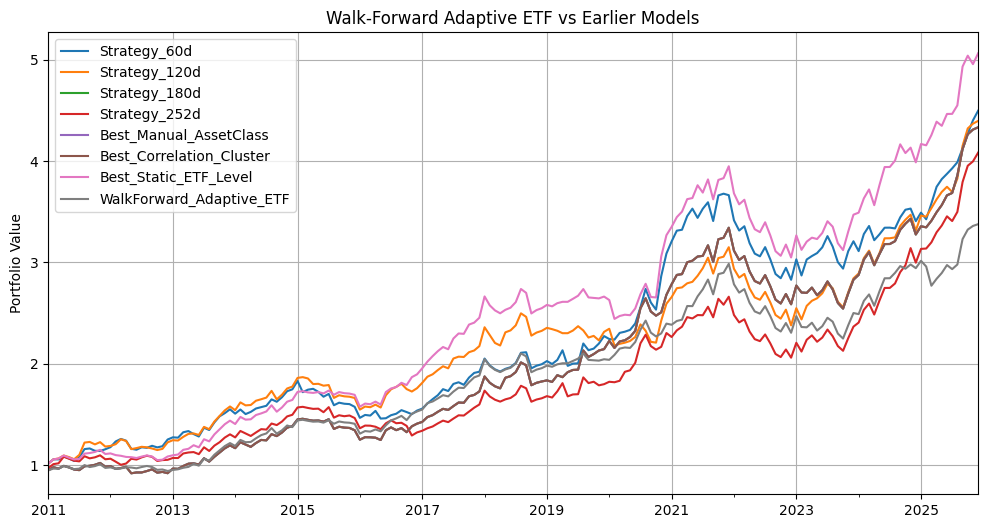

In [11]:
comparison_returns = pd.concat(
    [
        shared_baseline_returns,
        best_asset_class_returns.rename(columns={best_asset_class_returns.columns[0]: "Best_Manual_AssetClass"}),
        best_cluster_returns.rename(columns={best_cluster_returns.columns[0]: "Best_Correlation_Cluster"}),
        best_etf_static_returns.rename(columns={best_etf_static_returns.columns[0]: "Best_Static_ETF_Level"}),
        walk_forward_returns,
    ],
    axis=1
).dropna()

comparison_cumulative = (1 + comparison_returns).cumprod()
comparison_cumulative.plot(title="Walk-Forward Adaptive ETF vs Earlier Models")
plt.ylabel("Portfolio Value")
plt.show()

## 13. Compute performance metrics

In this section, I compute full-sample metrics for the compared strategies.

## Why this matters

This lets me quantify whether the walk-forward adaptive ETF model actually improved over the earlier approaches.

In [12]:
comparison_metrics = pd.DataFrame(
    {col: compute_metrics(comparison_returns[col]) for col in comparison_returns.columns}
).T

comparison_metrics

,CAGR,Annual Vol,Sharpe,Max Drawdown,Calmar
Strategy_60d,0.105421,0.117362,0.898254,-0.230909,0.456547
Strategy_120d,0.103754,0.115216,0.900512,-0.244820,0.423797
Strategy_180d,0.102694,0.112504,0.912810,-0.238701,0.430221
Strategy_252d,0.098334,0.115267,0.853093,-0.225921,0.435258
Best_Manual_AssetClass,0.102694,0.112504,0.912810,-0.238701,0.430221
Best_Correlation_Cluster,0.102694,0.112504,0.912810,-0.238701,0.430221
Best_Static_ETF_Level,0.114202,0.110069,1.037552,-0.227819,0.501284
WalkForward_Adaptive_ETF,0.084530,0.102208,0.827041,-0.246950,0.342297


## 14. Inspect selected ETF-level models through time

In this section, I inspect which ETF-level model was chosen in each rolling period.

## Why this matters

This helps me understand:
- whether the adaptive process is stable or chaotic
- whether the same ETF-level structure tends to keep winning
- how much the selected parameters move through time

In [13]:
selected_models_df

,Period,Train Start,Train End,Test Start,Test End,Selected Model
0,1,2006-01-31,2010-12-31,2011-01-31,2011-12-30,SPY_180_QQQ_180_IWM_60_EFA_60_EEM_252_TLT_252_...
1,2,2007-01-31,2011-12-30,2012-01-31,2012-12-31,SPY_60_QQQ_252_IWM_60_EFA_60_EEM_180_TLT_120_I...
2,3,2008-01-31,2012-12-31,2013-01-31,2013-12-31,SPY_120_QQQ_252_IWM_120_EFA_60_EEM_120_TLT_60_...
3,4,2009-01-30,2013-12-31,2014-01-31,2014-12-31,SPY_120_QQQ_252_IWM_120_EFA_60_EEM_120_TLT_60_...
4,5,2010-01-29,2014-12-31,2015-01-30,2015-12-31,SPY_120_QQQ_252_IWM_120_EFA_60_EEM_180_TLT_252...
5,6,2011-01-31,2015-12-31,2016-01-29,2016-12-30,SPY_120_QQQ_252_IWM_120_EFA_60_EEM_120_TLT_60_...
6,7,2012-01-31,2016-12-30,2017-01-31,2017-12-29,SPY_252_QQQ_252_IWM_120_EFA_60_EEM_120_TLT_180...
7,8,2013-01-31,2017-12-29,2018-01-31,2018-12-31,SPY_120_QQQ_252_IWM_120_EFA_60_EEM_180_TLT_120...
8,9,2014-01-31,2018-12-31,2019-01-31,2019-12-31,SPY_120_QQQ_252_IWM_120_EFA_60_EEM_180_TLT_120...
9,10,2015-01-30,2019-12-31,2020-01-31,2020-12-31,SPY_180_QQQ_180_IWM_60_EFA_60_EEM_252_TLT_252_...


## 15. Save walk-forward outputs

In this section, I save:
- the walk-forward adaptive returns
- the selected models through time
- the comparison metrics

## Why this matters

These artifacts will support the final comparison notebook and later dashboard integration.

In [14]:
walk_forward_returns.to_csv(PROCESSED_DIR / "walk_forward_adaptive_etf_returns.csv")
selected_models_df.to_csv(PROCESSED_DIR / "walk_forward_selected_models.csv", index=False)
comparison_metrics.to_csv(PROCESSED_DIR / "walk_forward_comparison_metrics.csv")

print("Saved walk-forward outputs to:", PROCESSED_DIR.resolve())

Saved walk-forward outputs to: /Users/nicholasturangan/Desktop/quant/quant-portfolio-project/data/processed


## 16. Key takeaways from this notebook

At this stage, I have tested a more realistic adaptive ETF-level research process.

## What I accomplished

- built a rolling 5-year walk-forward selection process
- re-selected ETF-level models using only past data
- applied selected models to future periods
- stitched together a realistic adaptive return series
- compared the walk-forward ETF model against earlier static models

## What I learned

This notebook helps answer whether ETF-level tuning is still useful when it is forced to adapt through time in a more realistic and less overfit way.

## What comes next

The next logical step is to:
- compare all final model families in one final comparison notebook
- add turnover and transaction-cost sensitivity
- decide which strategy is strongest overall
- begin planning how the dashboard/app should expose these engines